# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [126]:
# importar librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [127]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [128]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [129]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [130]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [131]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users",users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [132]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [133]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [134]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [135]:

# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean()*100)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [136]:
# cantidad de nulos para usage
print(usage.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 

 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  la columna city tiene 11.7 % de nulos y la columna churn_date tiene 88% de nulos
- Indica qué harías: ¿imputar, eliminar, ignorar? city es una columna categoríca por lo que los datos se imputarian y manejarían como desconocidos y para churn_date al ser datos que son de los usuarios que cancelaron se puede ignorar o construir una columna boleanan de usuarios que si cancelaron y no, idependeintemente de la desición, churn_date no afecta la calidad de los datos 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [169]:
# explorar columnas numéricas de users
users.describe()
#((users["age"] ==-999).sum()*100)/4000

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.136000
std,1154.844867,17.689919
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,48.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` es un identificador, no debería tratarse como nñumerico en los resúmenes estadísticos
- La columna "age" tiene valores sentinel como -999 que deben tratarse como NaN

In [138]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



- Las columnas `id` y `user_id`son un identificador, no debería tratarse como nímerico en los resúmenes estadísticos
- Las columnas duration y lenght no requieren modificaciones ya que los NaN tienen sentido logico


In [139]:
# explorar columnas categóricas de users
columnas_user = ["city", "plan"]
for col in columnas_user:
    print(users[col].value_counts())


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` cuenta con 7 valores unicos de los cuales 6 son ciudades y el septimo es ? que deberá tratarse como NaN
- La columna `plan` Cuenta con dos planes, premium y basico

In [140]:

# explorar columna categórica de usage
usage["type"].value_counts()


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` esta limpia


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  

- ¿En qué columnas encontraste valores inválidos o sentinels? en la columna de age se encuentra sentinel de -999 y en city con ?  
- ¿Qué acción tomarías?  se puede convertir en NaN o eliminar las filas 


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [141]:

# Convertir a fecha la columna `reg_date` de users
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce")
users["reg_date"].isna().sum()


0

In [142]:

# Convertir a fecha la columna `date` de usage
usage["date"] = pd.to_datetime(usage["date"], errors='coerce')
usage["date"].isna().sum()
(usage["date"].isna()).mean() * 100



0.125

In [143]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts().sort_index()
# Filtrar registros de 2026
#users[users['reg_date'].dt.year == 2026]

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observa dagos en el año 2026, se suguiere manejarlos como NaT para no perder informaciòn valiosa como de ciudad o años

In [144]:
# Revisar los años presentes en `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
usage['date'].dt.year.value_counts().sort_index()
#usage.shape[0]

2024.0    39950
Name: date, dtype: int64

En `date`, el 0.125% de las fechas no se pudieron convertir  Es un porcentaje muy bajo, así que no representa una pérdida significativa de información 
Basaremos el análisis en estas fechas.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)Obtenemos 40 registros del año 2026 en reg_date y 50 NaT en date
- ¿Qué harías con ellas?Para los 40 registros de 2026 en reg_date modificar a NaT para no perder registros importantes como city o age, Para los 50 NaT en usage['date'] (ese 0.125% del total): se puede conservar los datos y excluirlos en los analisis que requieran fecha


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [145]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'][users['age'] != -999].median()
users['age'] = users['age'].replace(-999, age_mediana)
#Mean y mediana (50%) deben acercarse
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [146]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
users['city'].isna().sum()
#Porcentaje que representa ese num
#users['city'].isna().mean() * 100

565

In [147]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] > pd.Timestamp.now(), 'reg_date'] = pd.NaT
# Verificar cambios
users['reg_date'].isna().sum()
#users['reg_date'].dtype

0

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [148]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna()
duration_missing = usage['duration'].isna()
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean() * 100)

type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [149]:
# Verificación MAR en usage (Missing At Random) para length
usage['length_missing'] = usage['length'].isna()
usage.groupby('type')['length_missing'].mean() * 100
usage.groupby('type')['length'].apply(lambda x: x.isna().mean() * 100)

type
call    99.932991
text     0.000000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Se detecta valores faltantes tipo MNAR relacionadas con la columna type, duration es nulo en todos los registros de tipo text, mientras que length es nulo prácticamente en todos los registros de tipo call. Esto indica un patrón de ausencia que se debe a que no existe para este tipo de registro, se recomienda mantenerlos como nulos y no imputarlos, evitando introducir información artificial en los datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [150]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes = ("is_text","sum"),
    cant_llamadas = ("is_call","sum"),
    cant_minutos_llamada = ("duration","sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [151]:
# Renombrar columnas
# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes = ("is_text","sum"),
    cant_llamadas = ("is_call","sum"),
    cant_minutos_llamada = ("duration","sum")
).reset_index()
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [152]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [153]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [154]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

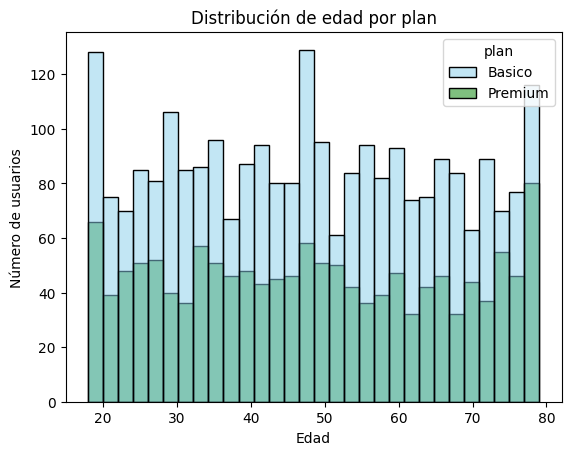

In [155]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan',
             palette=['skyblue', 'green'], bins=30)
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Número de usuarios')
plt.show()

💡Insights: 
La distribución de edad es relativamente uniforme entre los 18 y 80 años. El plan Básico presenta una mayor cantidad de usuarios en la mayoría de los rangos de edad, mientras que el plan Premium mantiene una distribución similar pero con menor frecuencia. No se observa un patrón claro que indique que alguno de los planes esté concentrado en un rango específico de edad.

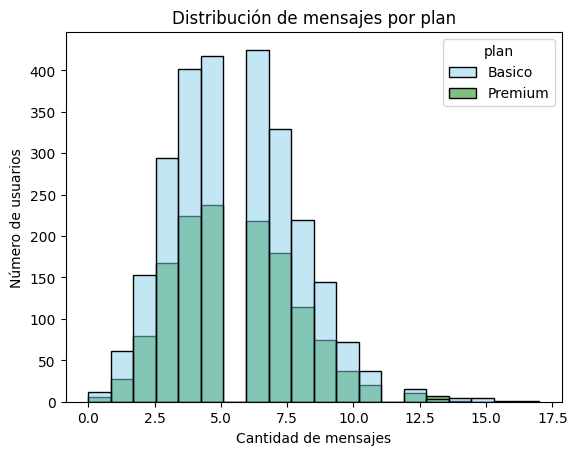

In [156]:

# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan',
             palette=['skyblue', 'green'], bins=20)
plt.title('Distribución de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Número de usuarios')
plt.show()


💡Insights: 
Los usuarios de ambos planes presentan una concentración de mensajes principalmente entre 3 y 9 mensajes, con mayor frecuencia alrededor de 4 a 7. El plan Básico presenta una mayor cantidad absoluta de usuarios, mientras que ambos planes muestran un comportamiento similar. La distribución presenta un sesgo hacia la derecha debido a la presencia de pocos usuarios con un número elevado de mensajes.

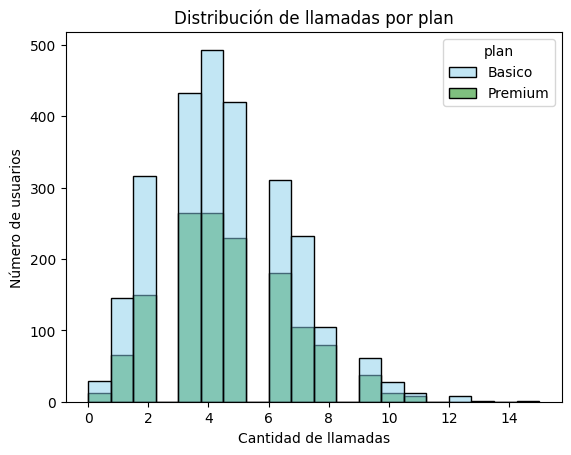

In [157]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan',
             palette=['skyblue', 'green'], bins=20)
plt.title('Distribución de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Número de usuarios')
plt.show()

💡Insights: 
- La distribución presenta un sesgo hacia la derecha debido a la presencia de pocos usuarios con un número elevado de llamadas, Los usuarios de ambos planes presentan una concentración de llamdas, principalmente entre 3 y 5 llamdas, con mayor frecuencia alrededor de 4 en plan basico y en plan premium 3  y 4. El plan Básico presenta una mayor cantidad absoluta de usuarios, mientras que ambos planes muestran un comportamiento similar.

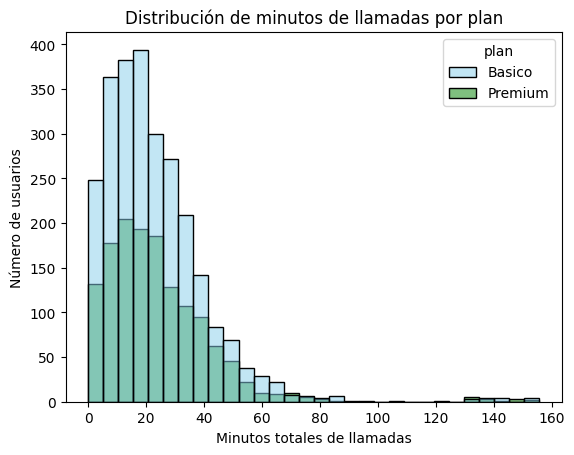

In [158]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan',
             palette=['skyblue', 'green'], bins=30)
plt.title('Distribución de minutos de llamadas por plan')
plt.xlabel('Minutos totales de llamadas')
plt.ylabel('Número de usuarios')
plt.show()

💡Insights: 
- Los usuarios de ambos planes presentan una concentración de minutos totales de llamadas principalmente entre 10 y 20 minutos, con mayor frecuencia alrededor de los 15 minutos totales de llamada. El plan Básico presenta una mayor cantidad absoluta de usuarios, mientras que ambos planes muestran un comportamiento similar. La distribución presenta un sesgo hacia la derecha debido a la presencia de pocos usuarios con muchos minutos totales de llamadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

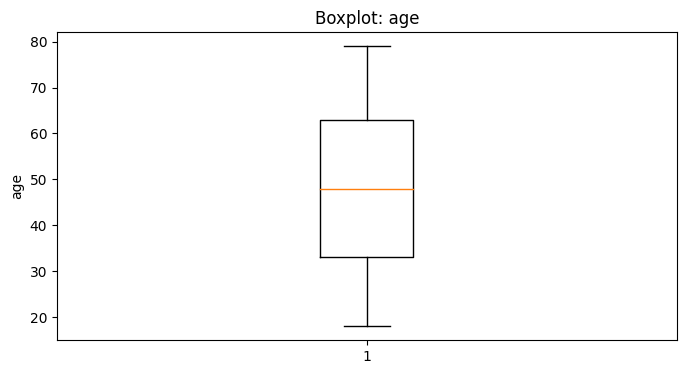

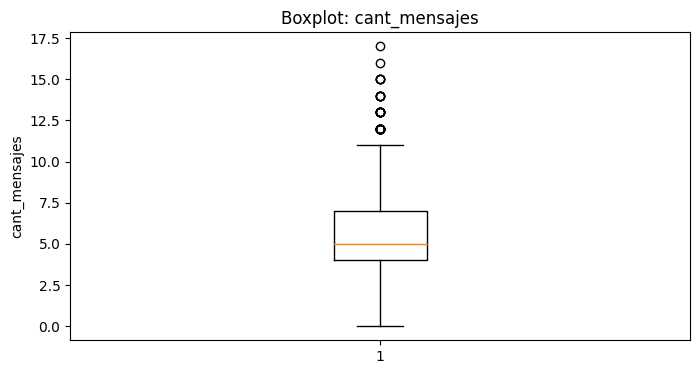

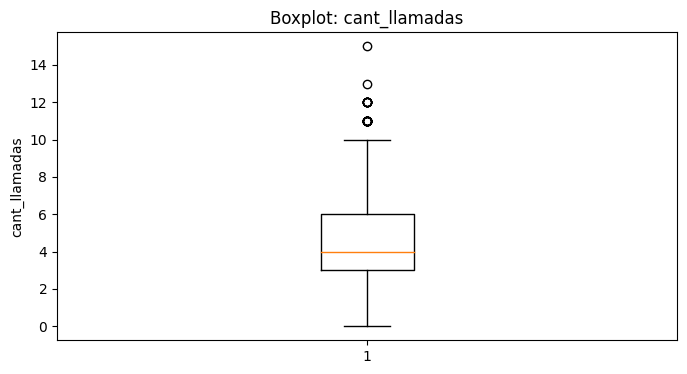

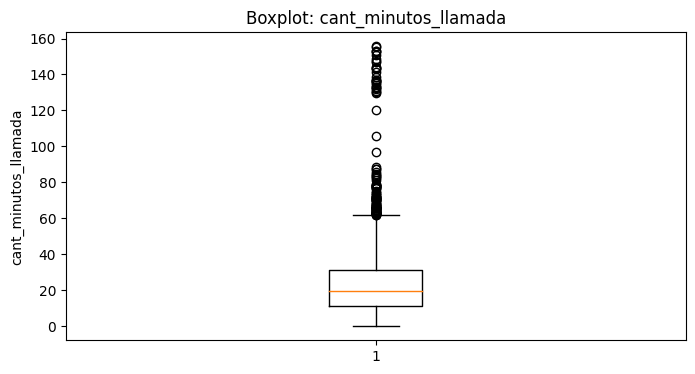

In [159]:
# Visualizando usando BoxPlot 
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    plt.boxplot(user_profile[col].dropna())
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()


💡Insights: 
- Age:No presenta outliers
- cant_mensajes: Presenta outliers superiores, lo que indica que existen usuarios con una cantidad de mensajes considerablemente mayor al comportamiento habitual.
- cant_llamadas: Presenta outliers superiores, debido a que algunos usuarios realizan una cantidad de llamadas significativamente mayor que el resto.
- cant_minutos_llamada: Presenta outliers superiores, lo que indica que existen usuarios cuyo tiempo total de llamadas es considerablemente mayor al comportamiento general.

In [160]:
# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)  
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    
    print(f'{col}:')
    print(f'Límite superior: {limite_superior:.2f}')


cant_mensajes:
Límite superior: 11.50
cant_llamadas:
Límite superior: 10.50
cant_minutos_llamada:
Límite superior: 61.86


In [161]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000



💡Insights: 
- cant_mensajes: Mantener los outliers, ya que los valores altos pueden representar usuarios con una actividad de mensajería elevada y no necesariamente errores en los datos
- cant_llamadas: Mantener los outliers, porque una cantidad elevada de llamadas puede corresponder a usuarios con un uso intensivo del servicio. Mantener los outliers, debido a que un tiempo de llamada elevado puede ser un comportamiento real de determinados usuarios. Aunque el máximo (155.69 min) supera considerablemente el límite superior (61.86 min), no implica que sea un error.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [162]:

# Crear columna grupo_uso
import numpy as np
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

valores = [
    'Bajo uso',
    'Uso medio'
]

user_profile['grupo_uso'] = np.select(
    condiciones,
    valores,
    default='Alto uso'
)
user_profile['grupo_uso'].value_counts()


Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

In [163]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [164]:

# Crear columna grupo_edad
condiciones_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

valores_edad = [
    'Joven',
    'Adulto'
]

user_profile['grupo_edad'] = np.select(
    condiciones_edad,
    valores_edad,
    default='Adulto Mayor'
)
user_profile['grupo_edad'].value_counts()


Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [165]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

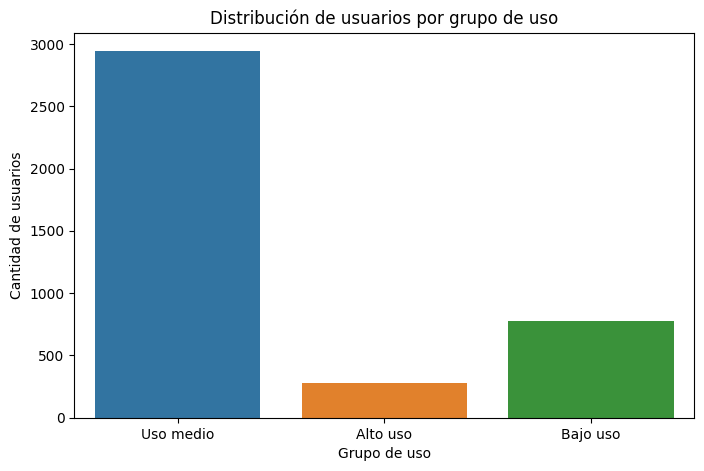

In [166]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))

sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

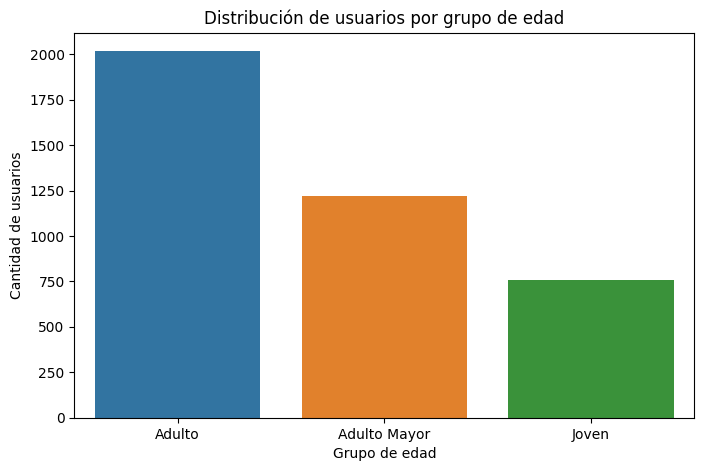

In [167]:
# Visualización de los segmentos por edad
# Visualización de los segmentos por edad

plt.figure(figsize=(8, 5))

sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders


🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

city: 11.7% de nulos + 2.715% con valor "?" (posible sentinel de texto)
age: 55 filas con valor -999 = 1.375% de las filas en columna age
reg_date: 40 filas con fechas futuras (imposibles)
date (en usage): 50 filas con NaT → 0.125%


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se identificaron dos tipos principales de segmentación:
Por edad:
Adultos: 2,018 clientes (50.5%).Adultos mayores: 1,222 clientes (30.6%).Jóvenes: 760 clientes (19.0%).
El segmento predominante es Adulto, representando aproximadamente la mitad de los clientes.
Por nivel de uso:
Uso medio: 2,943 clientes (73.6%).Bajo uso: 778 clientes (19.5%).Alto uso: 279 clientes (7.0%).

La mayor parte de los clientes presenta un uso medio, mientras que los usuarios de alto uso constituyen el segmento más pequeño.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
El segmento de alto uso puede ser especialmente valioso porque estos clientes presentan una mayor utilización del servicio. Aunque son únicamente 279 clientes, podrían representar una oportunidad para planes premium, paquetes con mayor capacidad o beneficios adicionales.
Por otro lado, los clientes de uso medio representan el 73.6% de la base, por lo que también son estratégicamente importantes. Una pequeña mejora en la conversión de este grupo hacia planes de mayor valor podría tener un impacto considerable debido al tamaño del segmento.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Mediante el método IQR se identificaron outliers superiores en:
cant_mensajes	lim sup. 11.50	max 17
cant_llamadas	lim sup. 10.50	max 15
cant_minutos_llamada	lim sup. 61.86	max 155.69

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Plan para usuarios de bajo uso: una opción económica con menor cantidad de llamadas y mensajes, dirigida a los 778 clientes de bajo uso.
Plan intermedio optimizado: mantener una oferta competitiva para el segmento de uso medio, que concentra 2,943 clientes y representa la mayor oportunidad por volumen.
Plan premium: desarrollar una opción para usuarios de alto consumo, con mayor cantidad de minutos, llamadas y mensajes, acompañada de beneficios adicionales.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo


⚠️ **Problemas detectados en los datos**
city: 11.7% de nulos + 2.715% con valor "?" (posible sentinel de texto)
age: 55 filas con valor -999 = 1.375% de las filas en columna age
reg_date: 40 filas con fechas futuras (imposibles)
date (en usage): 50 filas con NaT → 0.125%


🔍 **Segmentos por Edad**
Adultos: 2,018 clientes (50.5%), siendo el grupo predominante.
Adultos Mayores: 1,222 clientes (30.6%) y Jóvenes: 760 clientes (19.0%).


📊 **Segmentos por Nivel de Uso**
Uso medio: 2,943 clientes (73.6%), siendo el segmento principal.
Bajo uso: 778 clientes (19.5%) y Alto uso: 279 clientes (7.0%).


➡️ Esto sugiere que ...
la mayor parte de los clientes son adultos con un nivel de uso medio, mientras que el segmento de alto uso, aunque es pequeño, puede representar una oportunidad para ofrecer planes premium y aumentar el valor por cliente.

💡 **Recomendaciones**
Crear o ajustar planes diferenciados para usuarios de bajo, medio y alto consumo, considerando llamadas y mensajes.
Diseñar estrategias de upgrade para clientes de uso medio y planes premium para usuarios de alto consumo, aprovechando los patrones extremos identificados.
 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`